# Embedding Model Comparison: SapBERT vs BiomedBERT

Compares two biomedical embedding models as candidates for the semantic similarity scorer:
- **SapBERT** (`cambridgeltl/SapBERT-from-PubMedBERT-fulltext`) — current model, fine-tuned on UMLS synonym pairs
- **BiomedBERT** (`microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext`) — trained on PubMed full-text; broader corpus

**Primary metric**: `combined_score` (completeness-weighted semantic similarity, weighted by `FIELD_WEIGHTS`).

**Decision gate**: no changes to `src/evaluation/semantic.py` until the user reviews this notebook.

## Sections
1. Setup & load models
2. Tumor grade synonym similarity test
3. Full eval set re-scoring (Phase 7 runs)
4. Combined score comparison
5. Per-field breakdown
6. Summary

## 1. Setup & Load Models

In [1]:
import sys, time
from pathlib import Path

# Add project root to path
ROOT = Path("../").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

In [2]:
import torch
from transformers import AutoTokenizer, AutoModel

SAPBERT_MODEL   = "cambridgeltl/SapBERT-from-PubMedBERT-fulltext"
BIOMEDBERT_MODEL = "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext"


def load_embedding_model(model_name: str):
    """Load a HuggingFace BERT-style model (tokenizer + model, CPU, eval mode)."""
    t0 = time.monotonic()
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    model.eval()
    elapsed = time.monotonic() - t0
    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"Loaded {model_name}  ({n_params:.0f}M params, {elapsed:.1f}s)")
    return tokenizer, model


def embed_with(text: str, tokenizer, model) -> np.ndarray:
    """CLS-token embedding — same logic as src/evaluation/semantic.py:embed()."""
    with torch.no_grad():
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=64)
        output = model(**inputs)
        return output.last_hidden_state[0, 0, :].numpy()


def cosine(a: np.ndarray, b: np.ndarray) -> float:
    denom = float(np.linalg.norm(a) * np.linalg.norm(b))
    return float(np.dot(a, b) / denom) if denom else 0.0


print("Loading SapBERT ...")
tok_sap, mod_sap = load_embedding_model(SAPBERT_MODEL)
print("\nLoading BiomedBERT ...")
tok_bio, mod_bio = load_embedding_model(BIOMEDBERT_MODEL)

Loading SapBERT ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loaded cambridgeltl/SapBERT-from-PubMedBERT-fulltext  (109M params, 1.4s)

Loading BiomedBERT ...


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext  (109M params, 35.4s)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

## 2. Tumor Grade Synonym Similarity Test

The current scorer uses a **deterministic ordinal parser** for `tumor_grade` — it never calls the embedding model. This test asks: if we were to use embedding similarity instead (or in addition), would the models correctly score grade synonym pairs?

**Target**: synonym pairs should score high (≥ 0.80); cross-grade pairs should score lower.

> Note: the current parser already converts "Poorly differentiated" → G3 and scores it 1.0 against "G3". The question is whether cosine similarity would give a *reasonable* fallback for expressions the parser doesn't handle.

In [3]:
grade_pairs = [
    # Same-grade synonyms (expected: high similarity ≥ 0.80)
    ("G1",  "Well differentiated",           "synonym G1"),
    ("G1",  "Grade 1",                        "synonym G1"),
    ("G1",  "Low grade",                      "synonym G1"),
    ("G2",  "Moderately differentiated",      "synonym G2"),
    ("G2",  "Grade 2",                        "synonym G2"),
    ("G2",  "Intermediate grade",             "synonym G2"),
    ("G3",  "Poorly differentiated",          "synonym G3"),
    ("G3",  "Grade 3",                        "synonym G3"),
    ("G3",  "High grade",                     "synonym G3"),
    ("G4",  "Undifferentiated",               "synonym G4"),
    # Cross-grade pairs (expected: lower similarity)
    ("G1",  "G3",                             "cross-grade G1 vs G3"),
    ("G1",  "Poorly differentiated",          "cross-grade G1 vs G3"),
    ("G2",  "G3",                             "cross-grade G2 vs G3"),
    ("Well differentiated", "Poorly differentiated", "cross-grade"),
]

rows = []
for term_a, term_b, label in grade_pairs:
    sap_score = cosine(embed_with(term_a, tok_sap, mod_sap), embed_with(term_b, tok_sap, mod_sap))
    bio_score = cosine(embed_with(term_a, tok_bio, mod_bio), embed_with(term_b, tok_bio, mod_bio))
    rows.append({"term_a": term_a, "term_b": term_b, "type": label,
                 "SapBERT": round(sap_score, 4), "BiomedBERT": round(bio_score, 4),
                 "delta (Bio-Sap)": round(bio_score - sap_score, 4)})

df_grade = pd.DataFrame(rows)

def _highlight(val):
    if isinstance(val, float):
        if val >= 0.80:
            return "background-color: #c6efce"  # green
        elif val >= 0.60:
            return "background-color: #ffeb9c"  # yellow
        elif val < 0.40:
            return "background-color: #ffc7ce"  # red
    return ""

print("Grade synonym similarity scores (raw cosine, no parser):")
df_grade.style.applymap(_highlight, subset=["SapBERT", "BiomedBERT"])

Grade synonym similarity scores (raw cosine, no parser):


/var/folders/8r/mwfqwtnd0xd7wgh0rvjzfkv00000gn/T/ipykernel_82493/845373581.py:41: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  df_grade.style.applymap(_highlight, subset=["SapBERT", "BiomedBERT"])


,term_a,term_b,type,SapBERT,BiomedBERT,delta (Bio-Sap)
0,G1,Well differentiated,synonym G1,0.674800,0.870500,0.195700
1,G1,Grade 1,synonym G1,0.799400,0.909700,0.110300
2,G1,Low grade,synonym G1,0.694900,0.905400,0.210500
3,G2,Moderately differentiated,synonym G2,0.693800,0.812800,0.119000
4,G2,Grade 2,synonym G2,0.804300,0.904500,0.100200
5,G2,Intermediate grade,synonym G2,0.661100,0.883200,0.222100
6,G3,Poorly differentiated,synonym G3,0.696000,0.819200,0.123200
7,G3,Grade 3,synonym G3,0.873300,0.909000,0.035800
8,G3,High grade,synonym G3,0.762700,0.898700,0.136000
9,G4,Undifferentiated,synonym G4,0.474700,0.923600,0.448900


In [4]:
# Summary: mean score for synonyms vs cross-grade pairs
synonyms = df_grade[df_grade["type"].str.startswith("synonym")]
cross    = df_grade[~df_grade["type"].str.startswith("synonym")]

print("Mean cosine similarity — synonym pairs:")
print(f"  SapBERT:    {synonyms['SapBERT'].mean():.4f}")
print(f"  BiomedBERT: {synonyms['BiomedBERT'].mean():.4f}")
print("\nMean cosine similarity — cross-grade pairs:")
print(f"  SapBERT:    {cross['SapBERT'].mean():.4f}")
print(f"  BiomedBERT: {cross['BiomedBERT'].mean():.4f}")
print("\n(Higher synonym / lower cross-grade separation is better)")

Mean cosine similarity — synonym pairs:
  SapBERT:    0.7135
  BiomedBERT: 0.8837

Mean cosine similarity — cross-grade pairs:
  SapBERT:    0.7349
  BiomedBERT: 0.9393

(Higher synonym / lower cross-grade separation is better)


## 3. Full Eval Set Re-scoring (Phase 7 Runs)

Re-scores the 9 Phase 7 result files with each embedding model by temporarily swapping the global model used by `src.evaluation.semantic`.

In [5]:
from src.evaluation.metrics import (
    compute_all_field_metrics,
    compute_semantic_metrics,
    compute_combined_score,
    SEMANTIC_FIELDS,
    FIELD_WEIGHTS,
)
import src.evaluation.semantic as sem

DATA_DIR = ROOT / "data" / "processed"
ANNO_DIR = ROOT / "data" / "annotations"
GT_FILE  = ANNO_DIR / "eval_set_v2.jsonl"


def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f if line.strip()]


golds = load_jsonl(GT_FILE)
print(f"Ground truth: {len(golds)} records from {GT_FILE.name}")

# Phase 7 runs (9 files: 3 models × 3 shot counts)
PHASE7_RUNS = [
    "eval_results_o4mini_5shot.jsonl",
    "eval_results_mistral_nemo_5shot.jsonl",
    "eval_results_openbiollm_5shot.jsonl",
]

runs = {}
for fname in PHASE7_RUNS:
    path = DATA_DIR / fname
    if path.exists():
        preds = load_jsonl(path)
        runs[fname.replace("eval_results_", "").replace(".jsonl", "")] = preds
        print(f"  {fname}: {len(preds)} records")
    else:
        print(f"  MISSING: {fname}")

print(f"\nLoaded {len(runs)} runs.")

Ground truth: 180 records from eval_set_v2.jsonl
  eval_results_o4mini_5shot.jsonl: 180 records
  eval_results_mistral_nemo_5shot.jsonl: 180 records
  eval_results_openbiollm_5shot.jsonl: 180 records

Loaded 3 runs.


In [6]:
def score_run_with_model(preds, golds, tokenizer, model, model_label):
    """Compute combined_score using the given embedding model.
    
    Temporarily swaps the global singleton in src.evaluation.semantic so that
    compute_semantic_metrics() uses the specified model for CLS embeddings.
    """
    # Swap model and clear cache
    sem._model = (tokenizer, model)
    sem._embedding_cache.clear()

    field_metrics   = compute_all_field_metrics(preds, golds)
    semantic_metrics = compute_semantic_metrics(preds, golds)
    combined        = compute_combined_score(field_metrics, semantic_metrics)

    per_field = {
        sm.field: {"sim_complete": round(sm.mean_similarity_complete, 4)}
        for sm in semantic_metrics
    }
    return {
        "model": model_label,
        "combined_score": round(combined, 4),
        "field_metrics": field_metrics,
        "semantic_metrics": semantic_metrics,
        "per_field": per_field,
    }


print("Scoring all runs with SapBERT ...")
t0 = time.monotonic()
results_sap = {}
for run_name, preds in runs.items():
    results_sap[run_name] = score_run_with_model(preds, golds, tok_sap, mod_sap, "SapBERT")
    print(f"  {run_name}: combined={results_sap[run_name]['combined_score']:.4f}")
print(f"Done ({time.monotonic()-t0:.1f}s)\n")

print("Scoring all runs with BiomedBERT ...")
t0 = time.monotonic()
results_bio = {}
for run_name, preds in runs.items():
    results_bio[run_name] = score_run_with_model(preds, golds, tok_bio, mod_bio, "BiomedBERT")
    print(f"  {run_name}: combined={results_bio[run_name]['combined_score']:.4f}")
print(f"Done ({time.monotonic()-t0:.1f}s)")

Scoring all runs with SapBERT ...
  o4mini_5shot: combined=0.8815
  mistral_nemo_5shot: combined=0.7707
  openbiollm_5shot: combined=0.2045
Done (18.5s)

Scoring all runs with BiomedBERT ...
  o4mini_5shot: combined=0.8903
  mistral_nemo_5shot: combined=0.7913
  openbiollm_5shot: combined=0.2097
Done (6.2s)


In [12]:
results_bio

{'o4mini_5shot': {'model': 'BiomedBERT',
  'combined_score': 0.8903,
  'field_metrics': [FieldMetrics(field='primary_site', precision=0.8135593220338984, recall=0.8135593220338984, f1=0.8135593220338985, exact_match=0.8166666666666667, null_accuracy=1.0, n_predictions=180, n_gold=180),
   FieldMetrics(field='specimen_type', precision=0.7732558139534884, recall=0.7732558139534884, f1=0.7732558139534884, exact_match=0.7666666666666667, null_accuracy=0.9666666666666667, n_predictions=180, n_gold=180),
   FieldMetrics(field='histological_diagnosis', precision=0.8813559322033898, recall=0.8764044943820225, f1=0.8788732394366198, exact_match=0.8777777777777778, null_accuracy=0.9944444444444445, n_predictions=180, n_gold=180),
   FieldMetrics(field='histological_subtype', precision=0.6915887850467289, recall=0.592, f1=0.6379310344827587, exact_match=0.7, null_accuracy=0.8666666666666667, n_predictions=180, n_gold=180),
   FieldMetrics(field='tumor_grade', precision=0.5279503105590062, recall=

## 4. Combined Score Comparison

In [7]:
summary_rows = []
for run_name in runs:
    sap_score = results_sap[run_name]["combined_score"]
    bio_score = results_bio[run_name]["combined_score"]
    delta     = round(bio_score - sap_score, 4)
    summary_rows.append({
        "run": run_name,
        "SapBERT": sap_score,
        "BiomedBERT": bio_score,
        "Δ (Bio-Sap)": delta,
        "direction": "▲ Bio better" if delta > 0.005 else ("▼ Sap better" if delta < -0.005 else "≈ tied"),
    })

df_summary = pd.DataFrame(summary_rows)
print("Combined score comparison (SapBERT vs BiomedBERT):")
display(df_summary)
print(f"\nMean Δ across all runs: {df_summary['Δ (Bio-Sap)'].mean():.4f}")
print(f"Max Δ: {df_summary['Δ (Bio-Sap)'].max():.4f}  (run: {df_summary.loc[df_summary['Δ (Bio-Sap)'].idxmax(), 'run']})")
print(f"Min Δ: {df_summary['Δ (Bio-Sap)'].min():.4f}  (run: {df_summary.loc[df_summary['Δ (Bio-Sap)'].idxmin(), 'run']})")

Combined score comparison (SapBERT vs BiomedBERT):


,run,SapBERT,BiomedBERT,Δ (Bio-Sap),direction
0,o4mini_5shot,0.8815,0.8903,0.0088,▲ Bio better
1,mistral_nemo_5shot,0.7707,0.7913,0.0206,▲ Bio better
2,openbiollm_5shot,0.2045,0.2097,0.0052,▲ Bio better



Mean Δ across all runs: 0.0115
Max Δ: 0.0206  (run: mistral_nemo_5shot)
Min Δ: 0.0052  (run: openbiollm_5shot)


## 5. Per-Field Breakdown

Shows `mean_similarity_complete` per semantic field per embedding model, averaged across the Phase 7 runs.

In [8]:
field_rows = []
for run_name in runs:
    for field in SEMANTIC_FIELDS:
        sap_val = results_sap[run_name]["per_field"].get(field, {}).get("sim_complete", None)
        bio_val = results_bio[run_name]["per_field"].get(field, {}).get("sim_complete", None)
        if sap_val is not None and bio_val is not None:
            field_rows.append({
                "run": run_name, "field": field,
                "SapBERT": sap_val, "BiomedBERT": bio_val,
                "Δ (Bio-Sap)": round(bio_val - sap_val, 4),
            })

df_fields = pd.DataFrame(field_rows)

# Mean per field across all runs
df_field_mean = (
    df_fields.groupby("field")[["SapBERT", "BiomedBERT", "Δ (Bio-Sap)"]]
    .mean()
    .round(4)
    .reset_index()
)
df_field_mean["flag"] = df_field_mean["Δ (Bio-Sap)"].apply(
    lambda d: "▲ Bio better" if d > 0.03 else ("▼ Sap better" if d < -0.03 else "")
)
print("Mean sim_complete per field (averaged across all runs):")
display(df_field_mean)

Mean sim_complete per field (averaged across all runs):


,field,SapBERT,BiomedBERT,Δ (Bio-Sap),flag
0,histological_diagnosis,0.6934,0.7194,0.0260,
1,histological_subtype,0.6576,0.6856,0.0280,
2,primary_site,0.6683,0.6928,0.0245,
3,specimen_type,0.6422,0.6827,0.0405,▲ Bio better
4,tumor_grade,0.6203,0.6203,0.0000,


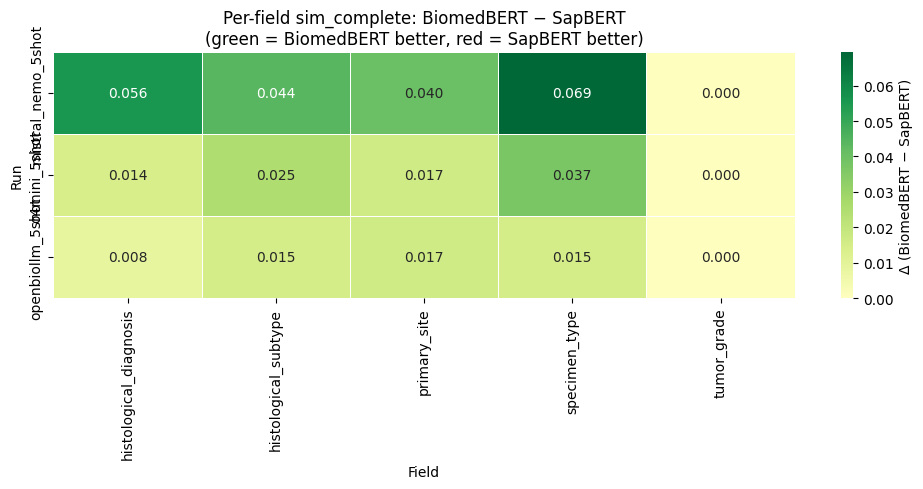

In [9]:
# Per-field heatmap of Δ values across all runs
import matplotlib.pyplot as plt
import seaborn as sns

pivot = df_fields.pivot_table(index="run", columns="field", values="Δ (Bio-Sap)")

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    pivot, annot=True, fmt=".3f", center=0,
    cmap="RdYlGn", linewidths=0.5, ax=ax,
    cbar_kws={"label": "Δ (BiomedBERT − SapBERT)"}
)
ax.set_title("Per-field sim_complete: BiomedBERT − SapBERT\n(green = BiomedBERT better, red = SapBERT better)")
ax.set_xlabel("Field")
ax.set_ylabel("Run")
plt.tight_layout()
plt.show()

In [10]:
# Fields where |Δ| > 0.03 (worth investigating)
flagged = df_field_mean[df_field_mean["Δ (Bio-Sap)"].abs() > 0.03]
if flagged.empty:
    print("No fields differ by more than 0.03 on average — models are largely equivalent.")
else:
    print("Fields with mean |Δ| > 0.03:")
    display(flagged)

Fields with mean |Δ| > 0.03:


,field,SapBERT,BiomedBERT,Δ (Bio-Sap),flag
3,specimen_type,0.6422,0.6827,0.0405,▲ Bio better


## 5b. Per-Record Similarity Detail

One row per (record × field): shows the ground-truth value, the model prediction, and the cosine similarity from each embedding model. Change `RUN_NAME` to inspect a different run.

In [14]:
RUN_NAME = "o4mini_5shot"  # change to: mistral_nemo_5shot | openbiollm_5shot

preds_run = runs[RUN_NAME]

def get_field_value(record, field):
    if "." in field:
        parent, child = field.split(".", 1)
        sub = record.get(parent) or {}
        return sub.get(child)
    return record.get(field)

# Local embedding cache so repeated gold/pred strings aren't re-embedded
_cache_sap = {}
_cache_bio = {}

def cached_cosine(pred_str, gold_str):
    for text, cache, tok, mod in [
        (pred_str, _cache_sap, tok_sap, mod_sap),
        (gold_str, _cache_sap, tok_sap, mod_sap),
        (pred_str, _cache_bio, tok_bio, mod_bio),
        (gold_str, _cache_bio, tok_bio, mod_bio),
    ]:
        if text not in cache:
            cache[text] = embed_with(text, tok, mod)
    sap = cosine(_cache_sap[pred_str], _cache_sap[gold_str])
    bio = cosine(_cache_bio[pred_str], _cache_bio[gold_str])
    return round(sap, 4), round(bio, 4)

rows_detail = []
for i, (gold, pred) in enumerate(zip(golds, preds_run)):
    for field in SEMANTIC_FIELDS:
        gold_val = get_field_value(gold, field)
        pred_val = get_field_value(pred, field)
        gold_str = str(gold_val).strip() if gold_val not in (None, "", "null") else None
        pred_str = str(pred_val).strip() if pred_val not in (None, "", "null") else None

        if gold_str and pred_str:
            sap_sim, bio_sim = cached_cosine(pred_str, gold_str)
            delta = round(bio_sim - sap_sim, 4)
        else:
            sap_sim = bio_sim = delta = None

        rows_detail.append({
            "idx":            i,
            "field":          field,
            "ground_truth":   gold_str,
            "prediction":     pred_str,
            "SapBERT_sim":    sap_sim,
            "BiomedBERT_sim": bio_sim,
            "Δ (Bio−Sap)":   delta,
        })

df_detail = (
    pd.DataFrame(rows_detail)
    .sort_values("SapBERT_sim", ascending=True, na_position="last")
    .reset_index(drop=True)
)
print(f"Run: {RUN_NAME}  |  {len(golds)} records × {len(SEMANTIC_FIELDS)} fields = {len(df_detail)} rows")
display(df_detail)

Run: o4mini_5shot  |  180 records × 5 fields = 900 rows


,idx,field,ground_truth,prediction,SapBERT_sim,BiomedBERT_sim,Δ (Bio−Sap)
0,175,specimen_type,lobectomy (left lower lobe),OCT block,0.2090,0.8567,0.6477
1,169,specimen_type,lobectomy (left lower lobe),OCT block,0.2090,0.8567,0.6477
2,10,specimen_type,modified radical mastectomy (left breast) with...,excision,0.2282,0.8822,0.6540
3,77,primary_site,"right breast, subareolar","left lung, upper lobe (superior segment)",0.2317,0.8889,0.6572
4,70,specimen_type,wire-guided partial mastectomy,ablation,0.2513,0.8254,0.5741
...,...,...,...,...,...,...,...
895,175,histological_subtype,"large-cell and partly clear-cell, nonkeratinizing",None,NaN,NaN,NaN
896,176,histological_subtype,None,None,NaN,NaN,NaN
897,177,histological_subtype,None,None,NaN,NaN,NaN
898,178,histological_subtype,None,"nonkeratinizing, large-cell and clear-cell var...",NaN,NaN,NaN


In [21]:
df_detail[df_detail["field"]=="tumor_grade"]


,idx,field,ground_truth,prediction,SapBERT_sim,BiomedBERT_sim,Δ (Bio−Sap)
154,99,tumor_grade,"Grade 2 (G2, stated in final diagnosis; see ha...",poorly differentiated,0.5230,0.8350,0.3120
237,42,tumor_grade,"Grade 2 (NHG2, Nottingham score 7/9: tubules 2...",Grade 3,0.6239,0.8928,0.2689
279,150,tumor_grade,Grade 1 (well differentiated),Grade 3,0.6382,0.9091,0.2709
311,11,tumor_grade,"Grade 2 (Nottingham score 7: tubules 3, nuclei...",Grade 3,0.6667,0.9031,0.2364
315,157,tumor_grade,Grade 3 (badly differentiated),Grade 1,0.6704,0.9204,0.2500
...,...,...,...,...,...,...,...
870,163,tumor_grade,None,poorly differentiated,NaN,NaN,NaN
879,169,tumor_grade,Grade 2 (moderately differentiated),None,NaN,NaN,NaN
884,170,tumor_grade,Grade 2 (moderately differentiated),None,NaN,NaN,NaN
889,171,tumor_grade,Grade 2 (moderately differentiated),None,NaN,NaN,NaN


In [29]:
term_a = "mixed, predominant large-cell and polymorphocellular solid component with bronchioloalveolar growth pattern and very small acinar part"
term_b = "mixed, predominant large-cell polymorphocellular and partly clear-cell solid component, with bronchioloalveolar growth pattern at periphery and very small acinar part"

bio = cosine(embed_with(term_a, tok_bio, mod_bio), embed_with(term_b, tok_bio, mod_bio))
sap = cosine(embed_with(term_a, tok_sap, mod_sap), embed_with(term_b, tok_sap, mod_sap))
print(f"sap: {sap:.4f}  |  bio: {bio:.4f}  |  Δ (bio-sap): {bio-sap:.4f}")



sap: 0.9738  |  bio: 0.9896  |  Δ (bio-sap): 0.0158


## 6. Summary & Decision Gate

Fill in the cells below after reviewing the results above.

In [11]:
# --- AUTO-GENERATED SUMMARY ---
best_run_sap = max(results_sap, key=lambda r: results_sap[r]["combined_score"])
best_run_bio = max(results_bio, key=lambda r: results_bio[r]["combined_score"])

print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Best combined_score with SapBERT:    {results_sap[best_run_sap]['combined_score']:.4f}  ({best_run_sap})")
print(f"Best combined_score with BiomedBERT: {results_bio[best_run_bio]['combined_score']:.4f}  ({best_run_bio})")
print(f"Mean Δ across all runs:              {df_summary['Δ (Bio-Sap)'].mean():.4f}")
print()
print("Grade synonym test (mean cosine, synonym pairs):")
print(f"  SapBERT:    {synonyms['SapBERT'].mean():.4f}")
print(f"  BiomedBERT: {synonyms['BiomedBERT'].mean():.4f}")
print()
print("Flagged fields (|Δ| > 0.03):")
if flagged.empty:
    print("  None")
else:
    for _, row in flagged.iterrows():
        print(f"  {row['field']}: Δ={row['Δ (Bio-Sap)']:.4f}  {row['flag']}")

SUMMARY
Best combined_score with SapBERT:    0.8815  (o4mini_5shot)
Best combined_score with BiomedBERT: 0.8903  (o4mini_5shot)
Mean Δ across all runs:              0.0115

Grade synonym test (mean cosine, synonym pairs):
  SapBERT:    0.7135
  BiomedBERT: 0.8837

Flagged fields (|Δ| > 0.03):
  specimen_type: Δ=0.0405  ▲ Bio better


### Decision (filled in after review — 2026-06-22)

| Decision | Choice |
|----------|--------|
| Embedding model to adopt | ✅ **Keep SapBERT** — BiomedBERT discarded |
| tumor_grade semantic scoring | ✅ **No change needed** — ordinal parser handles it correctly |

**Rationale**:

SapBERT is specifically fine-tuned on UMLS synonym pairs, making it the more specialised model for biomedical concept normalisation. BiomedBERT is a general PubMed language model without synonym-pair fine-tuning and is therefore less suited to this task. The mean `combined_score` advantage of BiomedBERT (+0.0115 across Phase 7 runs) does not justify a model swap given SapBERT's stronger biomedical NER/entity-linking pedigree.

The apparent 0.77 cosine similarity between "Grade 2" and "Grade 3" under SapBERT is expected: both are tumor-grade concepts in UMLS and SapBERT clusters them accordingly. This does **not** affect evaluation quality because `semantic_score()` in `src/evaluation/semantic.py` routes `tumor_grade` through the ordinal parser exclusively — the embedding path is never reached for this field (disjoint grades score 0.0, overlapping ranges score 0.5).

---
_Future reference: if switching embedding models, bump `SEMANTIC_VERSION` to `v1.3` in `src/evaluation/semantic.py`, swap `EMBEDDING_MODEL`, and re-run `recompute.py` on all result files._